## P-Value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)

df = pd.read_csv('coffee_dataset.csv')

In [2]:
sample_df = df.sample(150)
bootsample = sample_df.sample(150, replace=True)

null_mean = 70

In [3]:
means = []
for _ in range(10000):
    bootsample = sample_df.sample(150, replace=True)
    means.append(bootsample.height.mean())

print(f'sample standard dev:{np.std(means)}')

sample standard dev:0.2658246390555897


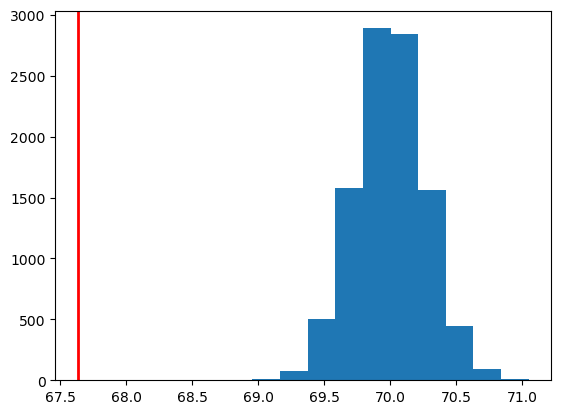

In [4]:
null_vals = np.random.normal(null_mean, np.std(means), 10000)

plt.hist(null_vals)
plt.axvline(sample_df.height.mean(), color='r', linewidth=2)

In [6]:
sample_mean = sample_df.height.mean()

pVal = (null_vals > sample_mean).mean()

print('null hypothesis: height <= 70')
print(f'sample mean: {sample_mean}')
print(f'p-value: {pVal}')

null hypothesis: height <= 70
sample mean: 67.63297688228059
p-value: 1.0


In [7]:
print('null hypothesis: height >= 70')

pVal = (null_vals < sample_mean).mean()
print(f'sample mean: {sample_mean}')
print(f'p-value: {pVal}')

null hypothesis: height >= 70
sample mean: 67.63297688228059
p-value: 0.0


In [10]:
null_vals > null_mean + (null_mean - sample_mean)

array([False, False, False, ..., False, False, False], shape=(10000,))

null hypothesis: height == 70
sample mean: 67.63297688228059
p-value: 0.0
low: 67.63297688228059
high: 72.36702311771941


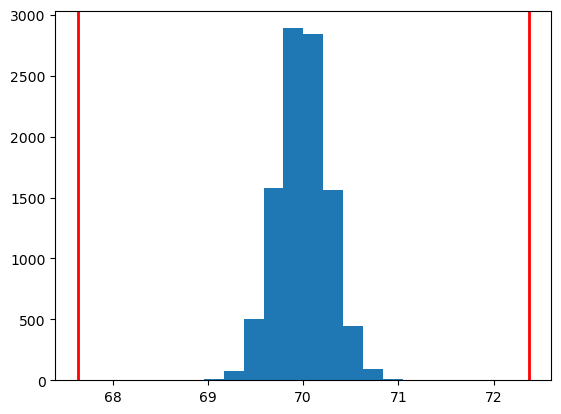

In [13]:
print('null hypothesis: height == 70')

pVal = (null_vals < sample_mean).mean() + (null_vals > null_mean + (null_mean - sample_mean)).mean()
print(f'sample mean: {sample_mean}')
print(f'p-value: {pVal}')

low = sample_mean
high = null_mean + (null_mean - sample_mean)

print(f'low: {low}')
print(f'high: {high}')

plt.hist(null_vals);
plt.axvline(low, color='r', linewidth=2);
plt.axvline(high, color='r', linewidth=2);